In [36]:
import matplotlib.pyplot as plt
from abbl_study_utils import ExperimentResult
import networkx as nx
import numpy as np
from itertools import cycle
from typing import Callable, Iterator
from scipy import stats

In [37]:
def load_data(
    name: str,
) -> tuple[ExperimentResult, "nx.Graph[str]", dict[str, np.ndarray]]:
    """Load experiment result and create graph with positions."""
    with open(f"../results/{name}.json", "r") as f:
        result = ExperimentResult.model_validate_json(f.read())

    name_graph: nx.Graph[str] = nx.Graph()
    name_graph.add_edges_from(
        (
            (result.dataset.agents[u].full_name, result.dataset.agents[v].full_name)
            for u, v in result.dataset.edges
        )
    )
    positions = nx.spring_layout(name_graph, seed=42)
    return result, name_graph, positions

In [38]:
def get_per_epoch_counts(result: ExperimentResult) -> list[int]:
    """Get count of agents with information per epoch."""
    return [
        sum(int(response.final_answer) for response in epoch)
        for epoch in result.epoch_agents_responses
    ]


def get_per_epoch_at_least_once_counts(result: ExperimentResult) -> Iterator[int]:
    """Get cumulative count of unique agents with information per epoch."""
    unique_agents: set[int] = set()
    for epoch in result.epoch_agents_responses:
        epoch_agents = {i for i, response in enumerate(epoch) if response.final_answer}
        unique_agents.update(epoch_agents)
        yield len(unique_agents)


def get_last_epoch_at_least_once_count(result: ExperimentResult) -> int:
    """Get the final cumulative count of unique agents with information."""
    return list(get_per_epoch_at_least_once_counts(result))[-1]


def create_confidence_interval_plot(
    data: list[tuple[str, list[ExperimentResult]]],
    y_label: str,
    filename: str,
    metric_fn: Callable = get_per_epoch_counts,
    ci_percentile: float = 0.25,
    title: str | None = None,
    ax=None,
) -> None:
    """Create a plot with confidence intervals for multiple experiments.

    For each experiment, shows mean ± CI based on multiple trials.
    The CI band is drawn between the (ci_percentile) and (1-ci_percentile) percentiles.

    Args:
        data: List of (label, [experiment_trials]) tuples
        title: Plot title
        metric_fn: Function to extract per-epoch values from an ExperimentResult
        ci_percentile: Percentile for CI boundaries (0.25 = 25th-75th percentile band)
        ax: Optional matplotlib axis to plot on (creates new figure if None)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    colors = plt.colormaps["tab10"].colors
    x = None

    for (label, results), color in zip(data, colors):
        # Build matrix: rows=trials, cols=epochs
        all_counts = [list(metric_fn(result)) for result in results]
        counts_matrix = np.array(all_counts)

        if x is None:
            x = np.arange(counts_matrix.shape[1]) + 1

        # Compute statistics across trials
        mean = np.mean(counts_matrix, axis=0)
        lower = np.percentile(counts_matrix, ci_percentile * 100, axis=0)
        upper = np.percentile(counts_matrix, (1 - ci_percentile) * 100, axis=0)

        # Plot CI band and mean line
        ax.fill_between(x, lower, upper, alpha=0.2, color=color)
        ax.plot(x, mean, label=label, color=color, marker="o", markersize=4)

    ax.set_xlabel("Epoch")
    ax.set_ylabel(y_label)
    if title:
        ax.set_title(title)
    ax.legend(loc="best")
    ax.grid(alpha=0.3)

    if ax is None:
        plt.tight_layout()
        plt.savefig(f"assets/{filename}", bbox_inches="tight")
        plt.show()


def create_side_by_side_confidence_interval_plots(
    data: list[tuple[str, list[ExperimentResult]]],
    title: str | None,
    filename: str,
    ci_percentile: float = 0.1,
) -> None:
    """Create side-by-side confidence interval plots for both metrics.

    Left subplot: per-epoch counts
    Right subplot: at-least-once counts
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left plot: per-epoch counts
    create_confidence_interval_plot(
        data,
        "Number of Agents",
        filename,
        metric_fn=get_per_epoch_counts,
        ci_percentile=ci_percentile,
        ax=axes[0],
        title=None,
    )

    # Right plot: at-least-once counts
    create_confidence_interval_plot(
        data,
        "Number of Agents (At Least Once)",
        filename,
        metric_fn=get_per_epoch_at_least_once_counts,
        ci_percentile=ci_percentile,
        ax=axes[1],
        title=None,
    )

    if title:
        fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"assets/{filename}", bbox_inches="tight")
    plt.show()


def create_at_least_once_confidence_interval_plot(
    data: list[tuple[str, list[ExperimentResult]]],
    title: str | None,
    filename: str,
    ci_percentile: float = 0.1,
) -> None:
    """Create a confidence interval plot for at-least-once counts."""
    create_confidence_interval_plot(
        data,
        title,
        filename,
        metric_fn=get_per_epoch_at_least_once_counts,
        ci_percentile=ci_percentile,
    )

In [39]:
# Load all trials for Modified Baseline
(
    study2_modified_baseline_agents25_trial0,
    study2_modified_baseline_agents25_trial0_graph,
    study2_modified_baseline_agents25_trial0_pos,
) = load_data("study2_modified_baseline_agents25_trial0")
(
    study2_modified_baseline_agents25_trial1,
    study2_modified_baseline_agents25_trial1_graph,
    study2_modified_baseline_agents25_trial1_pos,
) = load_data("study2_modified_baseline_agents25_trial1")
(
    study2_modified_baseline_agents25_trial2,
    study2_modified_baseline_agents25_trial2_graph,
    study2_modified_baseline_agents25_trial2_pos,
) = load_data("study2_modified_baseline_agents25_trial2")
(
    study2_modified_baseline_agents25_trial3,
    study2_modified_baseline_agents25_trial3_graph,
    study2_modified_baseline_agents25_trial3_pos,
) = load_data("study2_modified_baseline_agents25_trial3")
(
    study2_modified_baseline_agents25_trial4,
    study2_modified_baseline_agents25_trial4_graph,
    study2_modified_baseline_agents25_trial4_pos,
) = load_data("study2_modified_baseline_agents25_trial4")
(
    study2_modified_baseline_agents25_trial5,
    study2_modified_baseline_agents25_trial5_graph,
    study2_modified_baseline_agents25_trial5_pos,
) = load_data("study2_modified_baseline_agents25_trial5")
(
    study2_modified_baseline_agents25_trial6,
    study2_modified_baseline_agents25_trial6_graph,
    study2_modified_baseline_agents25_trial6_pos,
) = load_data("study2_modified_baseline_agents25_trial6")
(
    study2_modified_baseline_agents25_trial6,
    study2_modified_baseline_agents25_trial6_graph,
    study2_modified_baseline_agents25_trial6_pos,
) = load_data("study2_modified_baseline_agents25_trial6")
(
    study2_modified_baseline_agents25_trial7,
    study2_modified_baseline_agents25_trial7_graph,
    study2_modified_baseline_agents25_trial7_pos,
) = load_data("study2_modified_baseline_agents25_trial7")
(
    study2_modified_baseline_agents25_trial8,
    study2_modified_baseline_agents25_trial8_graph,
    study2_modified_baseline_agents25_trial8_pos,
) = load_data("study2_modified_baseline_agents25_trial8")
(
    study2_modified_baseline_agents25_trial9,
    study2_modified_baseline_agents25_trial9_graph,
    study2_modified_baseline_agents25_trial9_pos,
) = load_data("study2_modified_baseline_agents25_trial9")

# Load all trials for No BDI Simple
(
    study2_no_bdi_simple_agents25_trial0,
    study2_no_bdi_simple_agents25_trial0_graph,
    study2_no_bdi_simple_agents25_trial0_pos,
) = load_data("study2_no_bdi_simple_agents25_trial0")
(
    study2_no_bdi_simple_agents25_trial1,
    study2_no_bdi_simple_agents25_trial1_graph,
    study2_no_bdi_simple_agents25_trial1_pos,
) = load_data("study2_no_bdi_simple_agents25_trial1")
(
    study2_no_bdi_simple_agents25_trial2,
    study2_no_bdi_simple_agents25_trial2_graph,
    study2_no_bdi_simple_agents25_trial2_pos,
) = load_data("study2_no_bdi_simple_agents25_trial2")
(
    study2_no_bdi_simple_agents25_trial3,
    study2_no_bdi_simple_agents25_trial3_graph,
    study2_no_bdi_simple_agents25_trial3_pos,
) = load_data("study2_no_bdi_simple_agents25_trial3")
(
    study2_no_bdi_simple_agents25_trial4,
    study2_no_bdi_simple_agents25_trial4_graph,
    study2_no_bdi_simple_agents25_trial4_pos,
) = load_data("study2_no_bdi_simple_agents25_trial4")
(
    study2_no_bdi_simple_agents25_trial5,
    study2_no_bdi_simple_agents25_trial5_graph,
    study2_no_bdi_simple_agents25_trial5_pos,
) = load_data("study2_no_bdi_simple_agents25_trial5")
(
    study2_no_bdi_simple_agents25_trial6,
    study2_no_bdi_simple_agents25_trial6_graph,
    study2_no_bdi_simple_agents25_trial6_pos,
) = load_data("study2_no_bdi_simple_agents25_trial6")
(
    study2_no_bdi_simple_agents25_trial7,
    study2_no_bdi_simple_agents25_trial7_graph,
    study2_no_bdi_simple_agents25_trial7_pos,
) = load_data("study2_no_bdi_simple_agents25_trial7")
(
    study2_no_bdi_simple_agents25_trial8,
    study2_no_bdi_simple_agents25_trial8_graph,
    study2_no_bdi_simple_agents25_trial8_pos,
) = load_data("study2_no_bdi_simple_agents25_trial8")
(
    study2_no_bdi_simple_agents25_trial9,
    study2_no_bdi_simple_agents25_trial9_graph,
    study2_no_bdi_simple_agents25_trial9_pos,
) = load_data("study2_no_bdi_simple_agents25_trial9")

# Constants for experiment results
BASELINE_RESULTS: list[ExperimentResult] = [
    study2_modified_baseline_agents25_trial0,
    study2_modified_baseline_agents25_trial1,
    study2_modified_baseline_agents25_trial2,
    study2_modified_baseline_agents25_trial3,
    study2_modified_baseline_agents25_trial4,
    study2_modified_baseline_agents25_trial5,
    study2_modified_baseline_agents25_trial6,
    study2_modified_baseline_agents25_trial7,
    study2_modified_baseline_agents25_trial8,
    study2_modified_baseline_agents25_trial9,
]

NO_BDI_RESULTS: list[ExperimentResult] = [
    study2_no_bdi_simple_agents25_trial0,
    study2_no_bdi_simple_agents25_trial1,
    study2_no_bdi_simple_agents25_trial2,
    study2_no_bdi_simple_agents25_trial3,
    study2_no_bdi_simple_agents25_trial4,
    study2_no_bdi_simple_agents25_trial5,
    study2_no_bdi_simple_agents25_trial6,
    study2_no_bdi_simple_agents25_trial7,
    study2_no_bdi_simple_agents25_trial8,
    study2_no_bdi_simple_agents25_trial9,
]

# Extract last epoch at-least-once counts for statistical tests
BASELINE_LAST_EPOCH_COUNTS: list[int] = [
    get_last_epoch_at_least_once_count(result) for result in BASELINE_RESULTS
]
NO_BDI_LAST_EPOCH_COUNTS: list[int] = [
    get_last_epoch_at_least_once_count(result) for result in NO_BDI_RESULTS
]

In [40]:
# Data structure for plotting functions
DATA: list[tuple[str, list[ExperimentResult]]] = [
    ("Baseline", BASELINE_RESULTS),
    ("No BDI + Simple memory", NO_BDI_RESULTS),
]

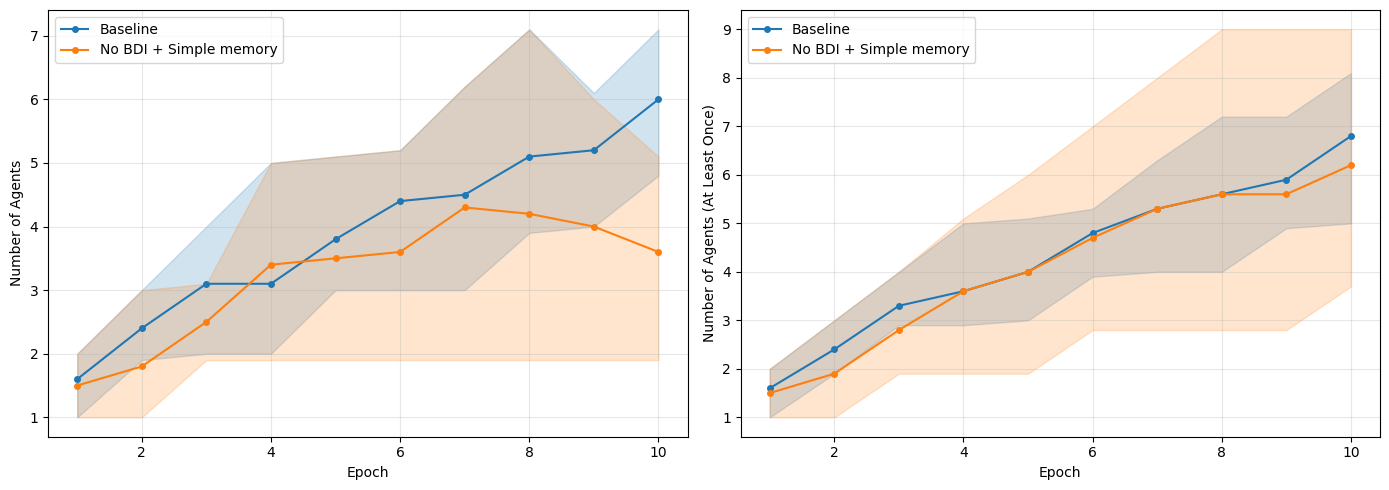

In [41]:
# Side-by-side plots
create_side_by_side_confidence_interval_plots(
    DATA,
    #"Information Spread Comparison",
    filename="study2_comparison.pdf",
    title=None
)

In [42]:
def create_token_histograms(
    data: list[tuple[str, list[ExperimentResult]]],
    filename: str,
    title: str = "Token Consumption Distribution",
) -> None:
    """Create side-by-side histograms for token consumption per experiment.
    Left subplot: prompt tokens
    Right subplot: completion tokens
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.colormaps["tab10"].colors
    for idx, (label, results) in enumerate(data):
        color = colors[idx]
        prompt_tokens = [r.prompt_tokens / 1e6 for r in results]
        completion_tokens = [r.completion_tokens / 1e6 for r in results]
        # Prompt tokens histogram
        axes[0].hist(
            prompt_tokens,
            bins=10,
            alpha=0.6,
            label=label,
            color=color,
            edgecolor="black",
            linewidth=0.5,
        )
        # Add mean line
        mean_prompt = np.mean(prompt_tokens)
        axes[0].axvline(
            mean_prompt,
            color=color,
            linestyle="--",
            linewidth=2,
            label=f"{label} mean: {mean_prompt:.2f}M",
        )
        # Completion tokens histogram
        axes[1].hist(
            completion_tokens,
            bins=10,
            alpha=0.6,
            label=label,
            color=color,
            edgecolor="black",
            linewidth=0.5,
        )
        # Add mean line
        mean_completion = np.mean(completion_tokens)
        axes[1].axvline(
            mean_completion,
            color=color,
            linestyle="--",
            linewidth=2,
            label=f"{label} mean: {mean_completion:.2f}M",
        )
    axes[0].set_xlabel("Prompt Tokens (Millions)")
    axes[0].set_ylabel("Frequency (Number of Trials)")
    axes[0].set_title("Prompt Token Distribution")
    axes[0].legend(loc="best")
    axes[0].grid(axis="y", alpha=0.3)
    axes[1].set_xlabel("Completion Tokens (Millions)")
    axes[1].set_ylabel("Frequency (Number of Trials)")
    axes[1].set_title("Completion Token Distribution")
    axes[1].legend(loc="best")
    axes[1].grid(axis="y", alpha=0.3)
    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"assets/{filename}", bbox_inches="tight")
    plt.show()


# def create_token_swarm_plot(
#     data: list[tuple[str, list[ExperimentResult]]],
#     filename: str,
#     title: str | None = None,
# ) -> None:
#     """Create strip plot showing individual trial token consumption."""
#     fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#     colors = plt.colormaps["tab10"].colors
#     labels = [label for label, _ in data]

#     for idx, (label, results) in enumerate(data):
#         color = colors[idx]

#         # Get token data
#         prompt_tokens = [r.prompt_tokens / 1e6 for r in results]
#         completion_tokens = [r.completion_tokens / 1e6 for r in results]

#         # Add jitter for visibility
#         jitter = np.random.uniform(-0.1, 0.1, len(results))
#         x_pos = idx + jitter

#         # Plot individual points with trial labels
#         axes[0].scatter(
#             x_pos, prompt_tokens, c=[color], s=100, alpha=0.7, edgecolors="black"
#         )
#         axes[1].scatter(
#             x_pos, completion_tokens, c=[color], s=100, alpha=0.7, edgecolors="black"
#         )

#         # Add trial number labels
#         # for i, (px, py) in enumerate(zip(x_pos, prompt_tokens)):
#         #     axes[0].annotate(f'T{i}', (px, py), textcoords='offset points',
#         #                    xytext=(0, 5), ha='center', fontsize=7)
#         # for i, (px, py) in enumerate(zip(x_pos, completion_tokens)):
#         #     axes[1].annotate(f'T{i}', (px, py), textcoords='offset points',
#         #                    xytext=(0, 5), ha='center', fontsize=7)

#         # Add mean line
#         mean_prompt = np.mean(prompt_tokens)
#         mean_completion = np.mean(completion_tokens)
#         axes[0].hlines(
#             mean_prompt,
#             idx - 0.3,
#             idx + 0.3,
#             colors=color,
#             linestyles="--",
#             linewidth=2,
#         )
#         axes[1].hlines(
#             mean_completion,
#             idx - 0.3,
#             idx + 0.3,
#             colors=color,
#             linestyles="--",
#             linewidth=2,
#         )
#     axes[0].set_xticks(range(len(labels)))
#     axes[0].set_xticklabels(labels, rotation=15, ha="right")
#     axes[0].set_ylabel("Prompt Tokens (Millions)")
#     axes[0].set_title("Prompt Token Distribution")
#     axes[0].grid(axis="y", alpha=0.3)
#     axes[1].set_xticks(range(len(labels)))
#     axes[1].set_xticklabels(labels, rotation=15, ha="right")
#     axes[1].set_ylabel("Completion Tokens (Millions)")
#     axes[1].set_title("Completion Token Distribution")
#     axes[1].grid(axis="y", alpha=0.3)
#     if title:
#         fig.suptitle(title, fontsize=14, fontweight="bold")
#     plt.tight_layout()
#     plt.savefig(f"assets/{filename}", bbox_inches="tight")
#     plt.show()


def create_token_swarm_individual_plot(
    data: list[tuple[str, list[ExperimentResult]]],
    filename: str,
    use_prompt_tokens: bool = True,
    title: str | None = None,
) -> None:
    """Create strip plot showing individual trial token consumption."""
    fig, axes = plt.subplots(1, 1, )
    colors = plt.colormaps["tab10"].colors
    labels = [label for label, _ in data]

    for idx, (label, results) in enumerate(data):
        color = colors[idx]

        # Get token data
        tokens = [
            r.prompt_tokens / 1e6 if use_prompt_tokens else r.completion_tokens / 1e6
            for r in results
        ]

        # Add jitter for visibility
        jitter = np.random.uniform(-0.2, 0.2, len(results))
        x_pos = idx + jitter

        # Plot individual points with trial labels
        axes.scatter(x_pos, tokens, c=[color], s=100, alpha=0.7, edgecolors="black")

        # Add mean line
        mean_prompt = np.mean(tokens)

        axes.hlines(
            mean_prompt,
            idx - 0.3,
            idx + 0.3,
            colors=color,
            linestyles="--",
            linewidth=2,
        )
    axes.set_xticks(range(len(labels)))
    axes.set_xticklabels(labels, rotation=15, ha="right")
    axes.set_ylabel("Prompt Tokens (Millions)")

    axes.grid(axis="y", alpha=0.3)

    if title:
        fig.suptitle(title, fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.savefig(f"assets/{filename}", bbox_inches="tight")
    plt.show()


def create_efficiency_scatter_plot(
    data: list[tuple[str, list[ExperimentResult]]],
    filename: str,
    title: str | None = None,
) -> None:
    """Create scatter plot showing efficiency: information spread vs tokens used.
    X-axis: Total tokens consumed (prompt + completion)
    Y-axis: Final epoch information spread (agents reached)
    """
    fig, ax = plt.subplots(figsize=(10, 7))  # Increased height for better layout
    colors = plt.colormaps["tab10"].colors
    for idx, (label, results) in enumerate(data):
        color = colors[idx]
        # Get final spread for each trial (at-least-once count)
        final_spreads = [
            get_last_epoch_at_least_once_count(result) for result in results
        ]
        # Get total tokens for each trial
        total_tokens = [(r.prompt_tokens + r.completion_tokens) / 1e6 for r in results]
        # Scatter plot with trial numbers as labels
        ax.scatter(
            total_tokens,
            final_spreads,
            c=[color],
            s=100,
            alpha=0.7,
            label=label,
            edgecolors="black",
            linewidth=1,
        )
        # Add trial number annotations
        # for i, (x, y) in enumerate(zip(total_tokens, final_spreads)):
        #     ax.annotate(
        #         f"T{i}",
        #         (x, y),
        #         textcoords="offset points",
        #         xytext=(5, 5),
        #         fontsize=8,
        #         alpha=0.7,
        #     )
        # Add mean point for this experiment
        mean_tokens = np.mean(total_tokens)
        mean_spread = np.mean(final_spreads)
        ax.scatter(
            [mean_tokens],
            [mean_spread],
            c=[color],
            s=300,
            marker="*",
            edgecolors="black",
            linewidth=2,
            label=f"{label} - mean",
            zorder=5,
        )
    ax.set_xlabel("Total Tokens (Millions)")
    ax.set_ylabel("Number of Agents")
    if title:
        ax.set_title(title)
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    # Add efficiency diagonal lines
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Calculate max_x for reference lines based on current limits
    max_x = xlim[1]
    max_y = ylim[1]
    # Add reference lines for efficiency (agents per million tokens)
    # Only draw lines that fit within the plot
    for efficiency in [5, 10, 20, 50]:
        # Calculate where this efficiency line would end
        y_at_max_x = efficiency * max_x
        if y_at_max_x <= max_y * 1.2:  # Allow slightly beyond limit for visibility
            x_ref = np.linspace(0, max_x, 100)
            y_ref = efficiency * x_ref
            ax.plot(x_ref, y_ref, "k--", alpha=0.2, linewidth=0.5)

            # Place label near the middle of the visible line
            label_idx = len(x_ref) // 2
            ax.text(
                x_ref[label_idx],
                y_ref[label_idx],
                f"{efficiency} agents/M",
                fontsize=8,
                alpha=0.5,
                va="bottom",
                ha="left",
                rotation=30,  # Rotate to follow line angle
            )
    plt.tight_layout()
    plt.savefig(f"assets/{filename}", bbox_inches="tight")
    plt.show()


def create_efficiency_bar_chart(
    data: list[tuple[str, list[ExperimentResult]]],
    filename: str,
    title: str | None = None,
) -> None:
    """Create bar chart comparing efficiency metrics across experiments.
    Shows:
    - Average total tokens per experiment
    - Average information spread (final epoch)
    - Efficiency ratio: agents reached per million tokens
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    colors = plt.colormaps["tab10"].colors
    labels = []
    avg_tokens = []
    avg_spread = []
    efficiency = []
    for label, results in data:
        labels.append(label)
        # Calculate metrics
        total_tokens_per_trial = [
            (r.prompt_tokens + r.completion_tokens) / 1e6 for r in results
        ]
        final_spread_per_trial = [
            get_last_epoch_at_least_once_count(result) for result in results
        ]
        avg_tokens.append(np.mean(total_tokens_per_trial))
        avg_spread.append(np.mean(final_spread_per_trial))
        efficiency.append(
            np.mean(final_spread_per_trial) / np.mean(total_tokens_per_trial)
            if np.mean(total_tokens_per_trial) > 0
            else 0
        )
    x = np.arange(len(labels))
    width = 0.6
    # Plot 1: Average total tokens
    bars1 = axes[0].bar(
        x, avg_tokens, width, color=[colors[i] for i in range(len(labels))]
    )
    axes[0].set_ylabel("Total Tokens (Millions)")
    axes[0].set_title("Average Token Consumption")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=15, ha="right")
    axes[0].grid(axis="y", alpha=0.3)
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        axes[0].annotate(
            f"{height:.2f}M",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    # Plot 2: Average information spread
    bars2 = axes[1].bar(
        x, avg_spread, width, color=[colors[i] for i in range(len(labels))]
    )
    axes[1].set_ylabel("Agents Reached")
    axes[1].set_title("Average Information Spread")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=15, ha="right")
    axes[1].grid(axis="y", alpha=0.3)
    # Add value labels on bars
    for bar in bars2:
        height = bar.get_height()
        axes[1].annotate(
            f"{height:.1f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    # Plot 3: Efficiency ratio
    bars3 = axes[2].bar(
        x, efficiency, width, color=[colors[i] for i in range(len(labels))]
    )
    axes[2].set_ylabel("Agents per Million Tokens")
    axes[2].set_title("Token Efficiency")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(labels, rotation=15, ha="right")
    axes[2].grid(axis="y", alpha=0.3)
    # Add value labels on bars
    for bar in bars3:
        height = bar.get_height()
        axes[2].annotate(
            f"{height:.1f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    if title:
        fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"assets/{filename}", bbox_inches="tight")
    plt.show()



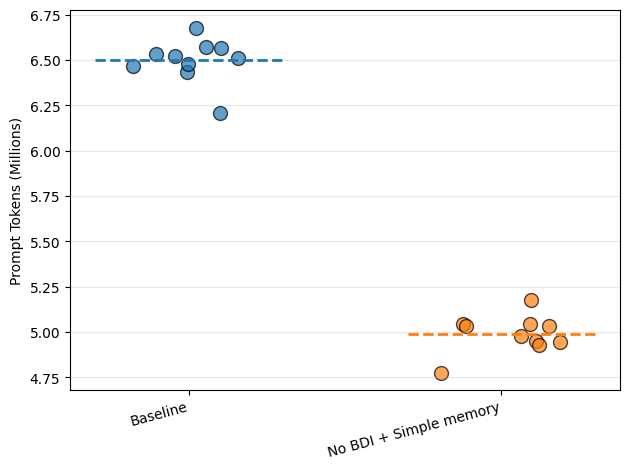

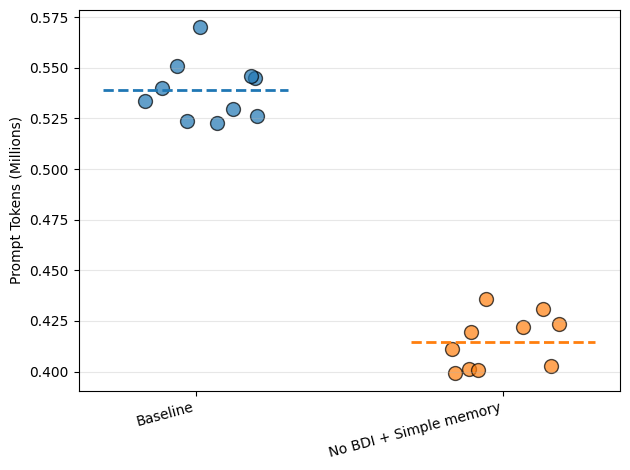

In [43]:
create_token_swarm_individual_plot(DATA, filename="study2_token_swarm_prompt.pdf", use_prompt_tokens=True)
create_token_swarm_individual_plot(DATA, filename="study2_token_swarm_completion.pdf", use_prompt_tokens=False)

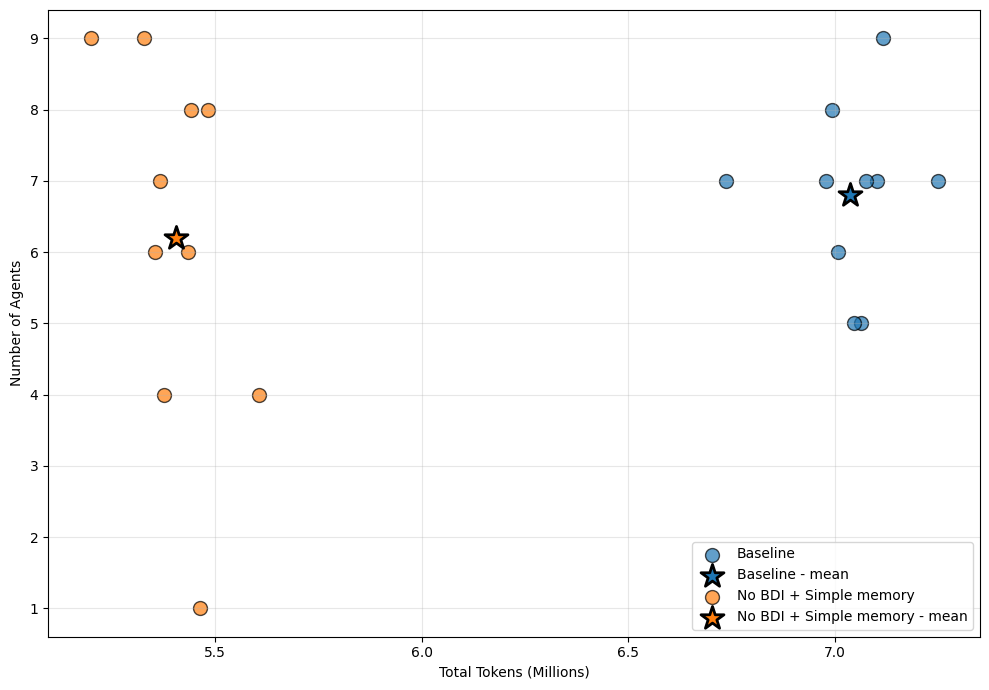

In [44]:
create_efficiency_scatter_plot(
    DATA,
    filename="study2_efficiency_scatter_plot.pdf",
    #title="Information Spread vs Token Efficiency",
)
# Number of reached agents in the last epoch vs total tokens consumed (at least once)

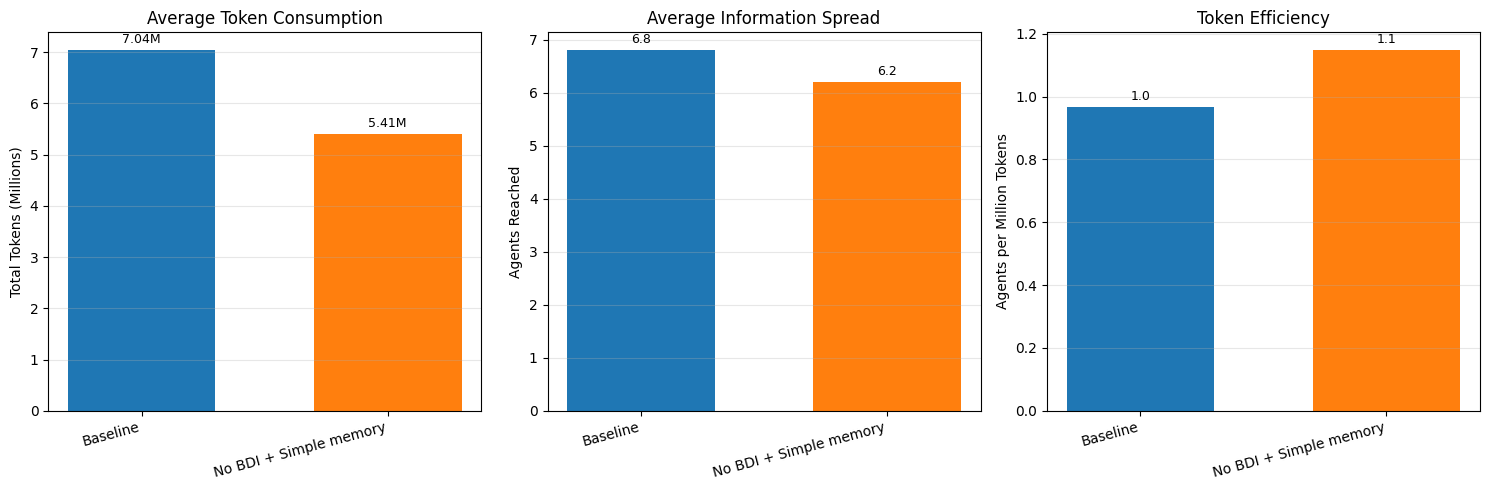

In [45]:
# Efficiency is a how many agents know the information in the final epoch / 1M tokens
create_efficiency_bar_chart(
    DATA,
    filename="study2_efficiency_bar_chart.pdf",
    #title="Token Efficiency Comparison",
)

## Per-Epoch Counts Statistical Tests

These tests analyze the number of agents with information in the last epoch.

In [46]:
# Extract last epoch per-epoch counts for statistical tests
BASELINE_LAST_EPOCH_PER_EPOCH_COUNTS: list[int] = [
    get_per_epoch_counts(result)[-1] for result in BASELINE_RESULTS
]
NO_BDI_LAST_EPOCH_PER_EPOCH_COUNTS: list[int] = [
    get_per_epoch_counts(result)[-1] for result in NO_BDI_RESULTS
]

# Perform Mann-Whitney U test (independent samples, non-parametric)
statistic, p_value = stats.mannwhitneyu(
    BASELINE_LAST_EPOCH_PER_EPOCH_COUNTS, NO_BDI_LAST_EPOCH_PER_EPOCH_COUNTS, alternative='two-sided'
)

print("Mann-Whitney U Test: Last Epoch Per-Epoch Counts")
print(f"{'='*60}")
print(f"Modified Baseline: {BASELINE_LAST_EPOCH_PER_EPOCH_COUNTS}")
print(f"No BDI Simple:     {NO_BDI_LAST_EPOCH_PER_EPOCH_COUNTS}")
print(f"{'='*60}")
print(f"U-statistic: {statistic}")
print(f"P-value:     {p_value:.4f}")
print(f"{'='*60}")
if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference (p >= 0.05)")

Mann-Whitney U Test: Last Epoch Per-Epoch Counts
Modified Baseline: [7, 6, 6, 7, 5, 3, 6, 8, 7, 5]
No BDI Simple:     [4, 6, 5, 2, 1, 3, 5, 4, 3, 3]
U-statistic: 88.0
P-value:     0.0041
Result: Statistically significant difference (p < 0.05)


In [47]:
# Perform independent samples t-test
t_statistic, t_p_value = stats.ttest_ind(BASELINE_LAST_EPOCH_PER_EPOCH_COUNTS, NO_BDI_LAST_EPOCH_PER_EPOCH_COUNTS)

print("Independent Samples t-Test: Last Epoch Per-Epoch Counts")
print(f"{'='*60}")
print(f"Modified Baseline: {BASELINE_LAST_EPOCH_PER_EPOCH_COUNTS}")
print(f"No BDI Simple:     {NO_BDI_LAST_EPOCH_PER_EPOCH_COUNTS}")
print(f"{'='*60}")
print(f"t-statistic: {t_statistic:.4f}")
print(f"P-value:     {t_p_value:.4f}")
print(f"{'='*60}")
if t_p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference (p >= 0.05)")

Independent Samples t-Test: Last Epoch Per-Epoch Counts
Modified Baseline: [7, 6, 6, 7, 5, 3, 6, 8, 7, 5]
No BDI Simple:     [4, 6, 5, 2, 1, 3, 5, 4, 3, 3]
t-statistic: 3.6742
P-value:     0.0017
Result: Statistically significant difference (p < 0.05)


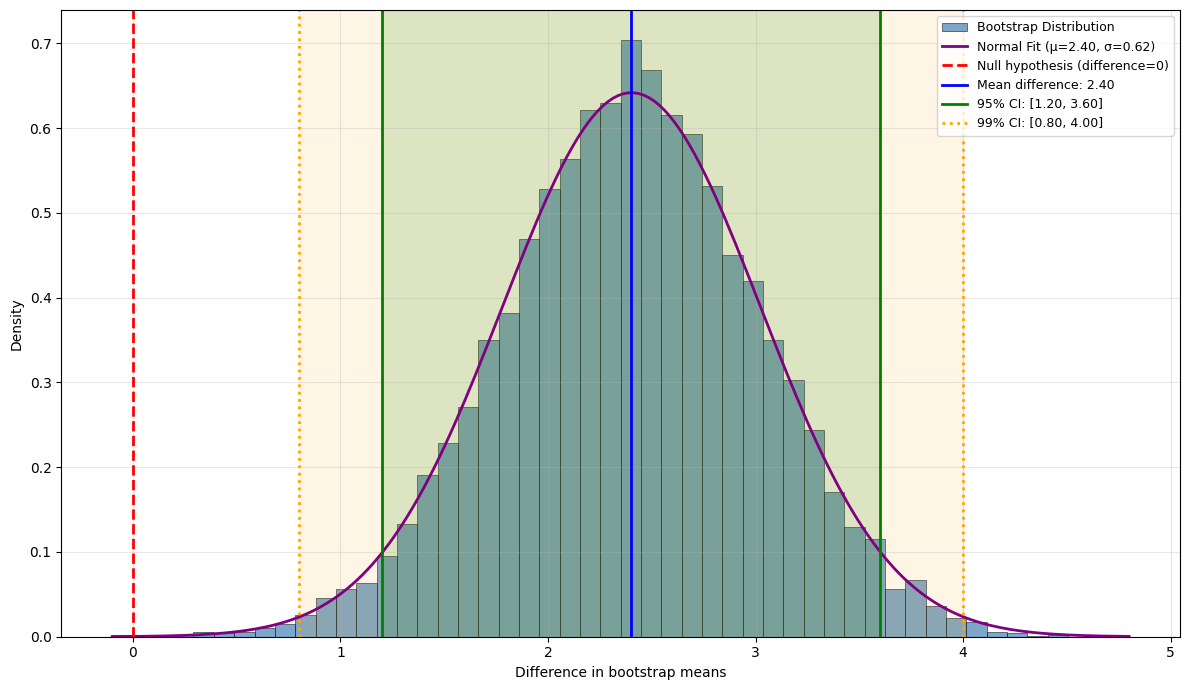

Bootstrap Analysis: Difference in Last Epoch Per-Epoch Counts
Modified Baseline mean: 6.00
No BDI Simple mean:     3.60
Observed difference:    2.40
Bootstrap mean difference: 2.40
Bootstrap std deviation:   0.62
Percentiles:
  1st:   0.90
  2.5th: 1.20
  5th:   1.40
  25th:  2.00
  50th:  2.40
  75th:  2.80
  95th:  3.40
  97.5th:3.60
  99th:  3.80
95% CI: [1.20, 3.60]
99% CI: [0.80, 4.00]
Bootstrap p-value (two-tailed): 0.0004
Result: 0 is NOT in 95% CI → Statistically significant difference


In [48]:
# Bootstrap analysis for difference in means
np.random.seed(42)
N_BOOTSTRAP = 10000

# Bootstrap sampling using list comprehension
bootstrap_diffs: np.ndarray = np.array([
    np.mean(np.random.choice(BASELINE_LAST_EPOCH_PER_EPOCH_COUNTS, size=len(BASELINE_LAST_EPOCH_PER_EPOCH_COUNTS), replace=True))
    - np.mean(np.random.choice(NO_BDI_LAST_EPOCH_PER_EPOCH_COUNTS, size=len(NO_BDI_LAST_EPOCH_PER_EPOCH_COUNTS), replace=True))
    for _ in range(N_BOOTSTRAP)
])

# Calculate percentiles and confidence intervals
percentiles: np.ndarray = np.percentile(bootstrap_diffs, [1, 2.5, 5, 25, 50, 75, 95, 97.5, 99])
ci_95: np.ndarray = np.percentile(bootstrap_diffs, [2.5, 97.5])
ci_99: np.ndarray = np.percentile(bootstrap_diffs, [0.5, 99.5])

# Fit normal distribution to bootstrap samples
mu, sigma = stats.norm.fit(bootstrap_diffs)

# Calculate p-value (proportion of bootstrap samples where difference <= 0)
p_value_bootstrap: float = min(np.mean(bootstrap_diffs <= 0) * 2, 1.0)  # Two-tailed, capped at 1.0

# Plot bootstrap distribution
fig, ax = plt.subplots(figsize=(12, 7))
ax.hist(bootstrap_diffs, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5, label='Bootstrap Distribution')

# Plot fitted normal distribution
x_norm = np.linspace(bootstrap_diffs.min(), bootstrap_diffs.max(), 200)
y_norm = stats.norm.pdf(x_norm, mu, sigma)
ax.plot(x_norm, y_norm, 'purple', linewidth=2, label=f'Normal Fit (μ={mu:.2f}, σ={sigma:.2f})')

# Add vertical lines for null hypothesis and mean
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Null hypothesis (difference=0)')
ax.axvline(mu, color='blue', linestyle='-', linewidth=2, label=f'Mean difference: {mu:.2f}')

# Add percentile markers
ax.axvline(ci_95[0], color='green', linestyle='-', linewidth=2, label=f'95% CI: [{ci_95[0]:.2f}, {ci_95[1]:.2f}]')
ax.axvline(ci_95[1], color='green', linestyle='-', linewidth=2)
ax.axvline(ci_99[0], color='orange', linestyle=':', linewidth=2, label=f'99% CI: [{ci_99[0]:.2f}, {ci_99[1]:.2f}]')
ax.axvline(ci_99[1], color='orange', linestyle=':', linewidth=2)

# Shade the CI regions
ax.axvspan(ci_95[0], ci_95[1], alpha=0.15, color='green')
ax.axvspan(ci_99[0], ci_99[1], alpha=0.1, color='orange')

ax.set_xlabel('Difference in bootstrap means')
ax.set_ylabel('Density')
#ax.set_title('Bootstrap - Per-Epoch Counts')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("assets/study2_bootstrap_last_epoch_distribution.pdf", bbox_inches="tight")
plt.show()

# Print results
print("Bootstrap Analysis: Difference in Last Epoch Per-Epoch Counts")
print(f"{'='*60}")
print(f"Modified Baseline mean: {np.mean(BASELINE_LAST_EPOCH_PER_EPOCH_COUNTS):.2f}")
print(f"No BDI Simple mean:     {np.mean(NO_BDI_LAST_EPOCH_PER_EPOCH_COUNTS):.2f}")
print(f"Observed difference:    {np.mean(BASELINE_LAST_EPOCH_PER_EPOCH_COUNTS) - np.mean(NO_BDI_LAST_EPOCH_PER_EPOCH_COUNTS):.2f}")
print(f"{'='*60}")
print(f"Bootstrap mean difference: {mu:.2f}")
print(f"Bootstrap std deviation:   {sigma:.2f}")
print(f"{'='*60}")
print("Percentiles:")
print(f"  1st:   {percentiles[0]:.2f}")
print(f"  2.5th: {percentiles[1]:.2f}")
print(f"  5th:   {percentiles[2]:.2f}")
print(f"  25th:  {percentiles[3]:.2f}")
print(f"  50th:  {percentiles[4]:.2f}")
print(f"  75th:  {percentiles[5]:.2f}")
print(f"  95th:  {percentiles[6]:.2f}")
print(f"  97.5th:{percentiles[7]:.2f}")
print(f"  99th:  {percentiles[8]:.2f}")
print(f"{'='*60}")
print(f"95% CI: [{ci_95[0]:.2f}, {ci_95[1]:.2f}]")
print(f"99% CI: [{ci_99[0]:.2f}, {ci_99[1]:.2f}]")
print(f"{'='*60}")
print(f"Bootstrap p-value (two-tailed): {p_value_bootstrap:.4f}")
if ci_95[0] > 0 or ci_95[1] < 0:
    print("Result: 0 is NOT in 95% CI → Statistically significant difference")
else:
    print("Result: 0 is in 95% CI → No statistically significant difference")

## At-Least-Once Counts Statistical Tests

These tests analyze the cumulative count of unique agents who received information at least once.

In [49]:
# Perform Mann-Whitney U test for at-least-once counts (independent samples, non-parametric)
statistic_alo, p_value_alo = stats.mannwhitneyu(
    BASELINE_LAST_EPOCH_COUNTS, NO_BDI_LAST_EPOCH_COUNTS, alternative='two-sided'
)

print("Mann-Whitney U Test: Last Epoch At-Least-Once Counts")
print(f"{'='*60}")
print(f"Modified Baseline: {BASELINE_LAST_EPOCH_COUNTS}")
print(f"No BDI Simple:     {NO_BDI_LAST_EPOCH_COUNTS}")
print(f"{'='*60}")
print(f"U-statistic: {statistic_alo}")
print(f"P-value:     {p_value_alo:.4f}")
print(f"{'='*60}")
if p_value_alo < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference (p >= 0.05)")

Mann-Whitney U Test: Last Epoch At-Least-Once Counts
Modified Baseline: [7, 9, 7, 7, 5, 5, 7, 8, 7, 6]
No BDI Simple:     [7, 8, 9, 4, 1, 6, 8, 9, 6, 4]
U-statistic: 53.5
P-value:     0.8173
Result: No statistically significant difference (p >= 0.05)


In [50]:
# Perform independent samples t-test for at-least-once counts
t_statistic_alo, t_p_value_alo = stats.ttest_ind(BASELINE_LAST_EPOCH_COUNTS, NO_BDI_LAST_EPOCH_COUNTS)

print("Independent Samples t-Test: Last Epoch At-Least-Once Counts")
print(f"{'='*60}")
print(f"Modified Baseline: {BASELINE_LAST_EPOCH_COUNTS}")
print(f"No BDI Simple:     {NO_BDI_LAST_EPOCH_COUNTS}")
print(f"{'='*60}")
print(f"t-statistic: {t_statistic_alo:.4f}")
print(f"P-value:     {t_p_value_alo:.4f}")
print(f"{'='*60}")
if t_p_value_alo < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference (p >= 0.05)")

Independent Samples t-Test: Last Epoch At-Least-Once Counts
Modified Baseline: [7, 9, 7, 7, 5, 5, 7, 8, 7, 6]
No BDI Simple:     [7, 8, 9, 4, 1, 6, 8, 9, 6, 4]
t-statistic: 0.6653
P-value:     0.5143
Result: No statistically significant difference (p >= 0.05)


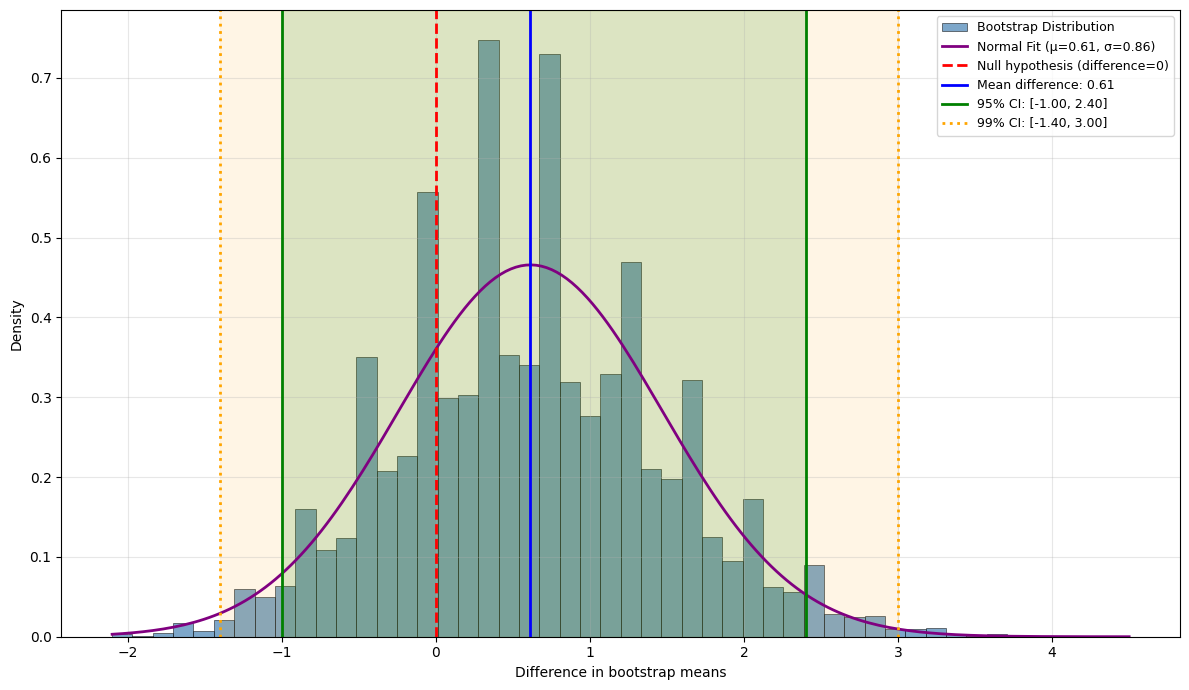

Bootstrap Analysis: Difference in Last Epoch At-Least-Once Counts
Modified Baseline mean: 6.80
No BDI Simple mean:     6.20
Observed difference:    0.60
Bootstrap mean difference: 0.61
Bootstrap std deviation:   0.86
Percentiles:
  1st:   -1.30
  2.5th: -1.00
  5th:   -0.80
  25th:  0.00
  50th:  0.60
  75th:  1.20
  95th:  2.10
  97.5th:2.40
  99th:  2.70
95% CI: [-1.00, 2.40]
99% CI: [-1.40, 3.00]
Bootstrap p-value (two-tailed): 0.5174
Result: 0 is in 95% CI → No statistically significant difference


In [51]:
# Bootstrap analysis for difference in means (at-least-once counts)
np.random.seed(42)

# Bootstrap sampling using list comprehension
bootstrap_diffs_alo: np.ndarray = np.array([
    np.mean(np.random.choice(BASELINE_LAST_EPOCH_COUNTS, size=len(BASELINE_LAST_EPOCH_COUNTS), replace=True))
    - np.mean(np.random.choice(NO_BDI_LAST_EPOCH_COUNTS, size=len(NO_BDI_LAST_EPOCH_COUNTS), replace=True))
    for _ in range(N_BOOTSTRAP)
])

# Calculate percentiles and confidence intervals
percentiles_alo: np.ndarray = np.percentile(bootstrap_diffs_alo, [1, 2.5, 5, 25, 50, 75, 95, 97.5, 99])
ci_95_alo: np.ndarray = np.percentile(bootstrap_diffs_alo, [2.5, 97.5])
ci_99_alo: np.ndarray = np.percentile(bootstrap_diffs_alo, [0.5, 99.5])

# Fit normal distribution to bootstrap samples
mu_alo, sigma_alo = stats.norm.fit(bootstrap_diffs_alo)

# Calculate p-value (proportion of bootstrap samples where difference <= 0)
p_value_bootstrap_alo: float = min(np.mean(bootstrap_diffs_alo <= 0) * 2, 1.0)  # Two-tailed, capped at 1.0

# Plot bootstrap distribution
fig, ax = plt.subplots(figsize=(12, 7))
ax.hist(bootstrap_diffs_alo, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5, label='Bootstrap Distribution')

# Plot fitted normal distribution
x_norm_alo = np.linspace(bootstrap_diffs_alo.min(), bootstrap_diffs_alo.max(), 200)
y_norm_alo = stats.norm.pdf(x_norm_alo, mu_alo, sigma_alo)
ax.plot(x_norm_alo, y_norm_alo, 'purple', linewidth=2, label=f'Normal Fit (μ={mu_alo:.2f}, σ={sigma_alo:.2f})')

# Add vertical lines for null hypothesis and mean
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Null hypothesis (difference=0)')
ax.axvline(mu_alo, color='blue', linestyle='-', linewidth=2, label=f'Mean difference: {mu_alo:.2f}')

# Add percentile markers
ax.axvline(ci_95_alo[0], color='green', linestyle='-', linewidth=2, label=f'95% CI: [{ci_95_alo[0]:.2f}, {ci_95_alo[1]:.2f}]')
ax.axvline(ci_95_alo[1], color='green', linestyle='-', linewidth=2)
ax.axvline(ci_99_alo[0], color='orange', linestyle=':', linewidth=2, label=f'99% CI: [{ci_99_alo[0]:.2f}, {ci_99_alo[1]:.2f}]')
ax.axvline(ci_99_alo[1], color='orange', linestyle=':', linewidth=2)

# Shade the CI regions
ax.axvspan(ci_95_alo[0], ci_95_alo[1], alpha=0.15, color='green')
ax.axvspan(ci_99_alo[0], ci_99_alo[1], alpha=0.1, color='orange')

ax.set_xlabel('Difference in bootstrap means')
ax.set_ylabel('Density')
#ax.set_title('Bootstrap - At-Least-Once Counts')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("assets/study2_bootstrap_atleastonce_distribution.pdf", bbox_inches="tight")
plt.show()

# Print results
print("Bootstrap Analysis: Difference in Last Epoch At-Least-Once Counts")
print(f"{'='*60}")
print(f"Modified Baseline mean: {np.mean(BASELINE_LAST_EPOCH_COUNTS):.2f}")
print(f"No BDI Simple mean:     {np.mean(NO_BDI_LAST_EPOCH_COUNTS):.2f}")
print(f"Observed difference:    {np.mean(BASELINE_LAST_EPOCH_COUNTS) - np.mean(NO_BDI_LAST_EPOCH_COUNTS):.2f}")
print(f"{'='*60}")
print(f"Bootstrap mean difference: {mu_alo:.2f}")
print(f"Bootstrap std deviation:   {sigma_alo:.2f}")
print(f"{'='*60}")
print("Percentiles:")
print(f"  1st:   {percentiles_alo[0]:.2f}")
print(f"  2.5th: {percentiles_alo[1]:.2f}")
print(f"  5th:   {percentiles_alo[2]:.2f}")
print(f"  25th:  {percentiles_alo[3]:.2f}")
print(f"  50th:  {percentiles_alo[4]:.2f}")
print(f"  75th:  {percentiles_alo[5]:.2f}")
print(f"  95th:  {percentiles_alo[6]:.2f}")
print(f"  97.5th:{percentiles_alo[7]:.2f}")
print(f"  99th:  {percentiles_alo[8]:.2f}")
print(f"{'='*60}")
print(f"95% CI: [{ci_95_alo[0]:.2f}, {ci_95_alo[1]:.2f}]")
print(f"99% CI: [{ci_99_alo[0]:.2f}, {ci_99_alo[1]:.2f}]")
print(f"{'='*60}")
print(f"Bootstrap p-value (two-tailed): {p_value_bootstrap_alo:.4f}")
if ci_95_alo[0] > 0 or ci_95_alo[1] < 0:
    print("Result: 0 is NOT in 95% CI → Statistically significant difference")
else:
    print("Result: 0 is in 95% CI → No statistically significant difference")

## Token Efficiency Statistical Tests

These tests analyze the efficiency of information spread (agents reached per million tokens).

In [52]:
# Calculate token efficiency for each trial (agents reached per million tokens)
# Uses same logic as create_efficiency_scatter_plot: per-epoch count in last epoch
BASELINE_TOKEN_EFFICIENCY: list[float] = [
    get_last_epoch_at_least_once_count(result)
    / ((result.prompt_tokens + result.completion_tokens) / 1e6)
    for result in BASELINE_RESULTS
]
NO_BDI_TOKEN_EFFICIENCY: list[float] = [
    get_last_epoch_at_least_once_count(result)
    / ((result.prompt_tokens + result.completion_tokens) / 1e6)
    for result in NO_BDI_RESULTS
]

print("Token Efficiency (agents per million tokens):")
print(f"{'='*60}")
print(f"Modified Baseline: {[f'{e:.2f}' for e in BASELINE_TOKEN_EFFICIENCY]}")
print(f"No BDI Simple:     {[f'{e:.2f}' for e in NO_BDI_TOKEN_EFFICIENCY]}")
print(f"{'='*60}")
print(f"Modified Baseline mean: {np.mean(BASELINE_TOKEN_EFFICIENCY):.2f}")
print(f"No BDI Simple mean:     {np.mean(NO_BDI_TOKEN_EFFICIENCY):.2f}")

Token Efficiency (agents per million tokens):
Modified Baseline: ['1.00', '1.26', '1.04', '0.97', '0.71', '0.71', '0.99', '1.14', '0.99', '0.86']
No BDI Simple:     ['1.30', '1.46', '1.73', '0.71', '0.18', '1.12', '1.47', '1.69', '1.10', '0.74']
Modified Baseline mean: 0.97
No BDI Simple mean:     1.15


In [53]:
# Mann-Whitney U test for token efficiency
statistic_eff, p_value_eff = stats.mannwhitneyu(
    BASELINE_TOKEN_EFFICIENCY, NO_BDI_TOKEN_EFFICIENCY, alternative='two-sided'
)

print("Mann-Whitney U Test: Token Efficiency")
print(f"{'='*60}")
print(f"Modified Baseline: {[f'{e:.2f}' for e in BASELINE_TOKEN_EFFICIENCY]}")
print(f"No BDI Simple:     {[f'{e:.2f}' for e in NO_BDI_TOKEN_EFFICIENCY]}")
print(f"{'='*60}")
print(f"U-statistic: {statistic_eff}")
print(f"P-value:     {p_value_eff:.4f}")
print(f"{'='*60}")
if p_value_eff < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference (p >= 0.05)")

Mann-Whitney U Test: Token Efficiency
Modified Baseline: ['1.00', '1.26', '1.04', '0.97', '0.71', '0.71', '0.99', '1.14', '0.99', '0.86']
No BDI Simple:     ['1.30', '1.46', '1.73', '0.71', '0.18', '1.12', '1.47', '1.69', '1.10', '0.74']
U-statistic: 30.0
P-value:     0.1405
Result: No statistically significant difference (p >= 0.05)


In [54]:
# Independent samples t-test for token efficiency
t_statistic_eff, t_p_value_eff = stats.ttest_ind(BASELINE_TOKEN_EFFICIENCY, NO_BDI_TOKEN_EFFICIENCY)

print("Independent Samples t-Test: Token Efficiency")
print(f"{'='*60}")
print(f"Modified Baseline: {[f'{e:.2f}' for e in BASELINE_TOKEN_EFFICIENCY]}")
print(f"No BDI Simple:     {[f'{e:.2f}' for e in NO_BDI_TOKEN_EFFICIENCY]}")
print(f"{'='*60}")
print(f"t-statistic: {t_statistic_eff:.4f}")
print(f"P-value:     {t_p_value_eff:.4f}")
print(f"{'='*60}")
if t_p_value_eff < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference (p >= 0.05)")

Independent Samples t-Test: Token Efficiency
Modified Baseline: ['1.00', '1.26', '1.04', '0.97', '0.71', '0.71', '0.99', '1.14', '0.99', '0.86']
No BDI Simple:     ['1.30', '1.46', '1.73', '0.71', '0.18', '1.12', '1.47', '1.69', '1.10', '0.74']
t-statistic: -1.1311
P-value:     0.2729
Result: No statistically significant difference (p >= 0.05)


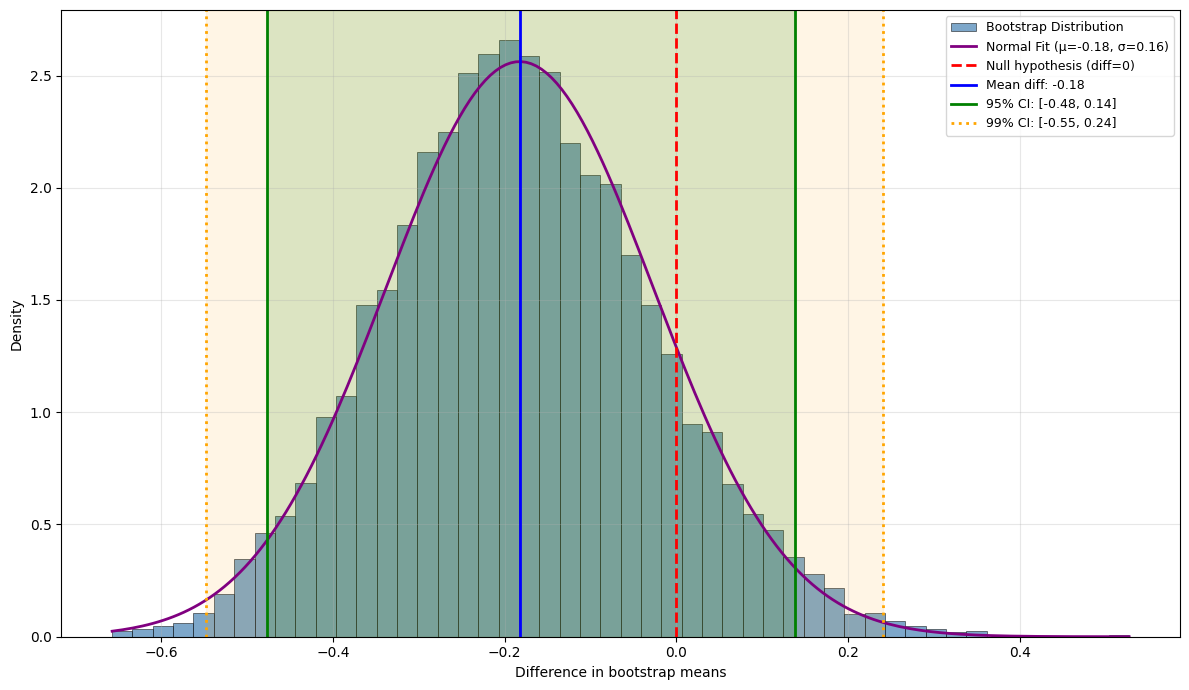

Bootstrap Analysis: Difference in Token Efficiency
Modified Baseline mean: 0.97 agents/M tokens
No BDI Simple mean:     1.15 agents/M tokens
Observed difference:    -0.19
Bootstrap mean difference: -0.18
Bootstrap std deviation:   0.16
Percentiles:
  1st:   -0.52
  2.5th: -0.48
  5th:   -0.43
  25th:  -0.29
  50th:  -0.19
  75th:  -0.08
  95th:  0.09
  97.5th:0.14
  99th:  0.19
95% CI: [-0.48, 0.14]
99% CI: [-0.55, 0.24]
Bootstrap p-value (two-tailed): 1.0000
Result: 0 is in 95% CI → No statistically significant difference


In [55]:
# Bootstrap analysis for token efficiency difference
np.random.seed(42)

# Bootstrap sampling
bootstrap_eff_diffs: np.ndarray = np.array([
    np.mean(np.random.choice(BASELINE_TOKEN_EFFICIENCY, size=len(BASELINE_TOKEN_EFFICIENCY), replace=True))
    - np.mean(np.random.choice(NO_BDI_TOKEN_EFFICIENCY, size=len(NO_BDI_TOKEN_EFFICIENCY), replace=True))
    for _ in range(N_BOOTSTRAP)
])

# Calculate percentiles and confidence intervals
percentiles_eff: np.ndarray = np.percentile(bootstrap_eff_diffs, [1, 2.5, 5, 25, 50, 75, 95, 97.5, 99])
ci_95_eff: np.ndarray = np.percentile(bootstrap_eff_diffs, [2.5, 97.5])
ci_99_eff: np.ndarray = np.percentile(bootstrap_eff_diffs, [0.5, 99.5])

# Fit normal distribution
mu_eff, sigma_eff = stats.norm.fit(bootstrap_eff_diffs)

# Calculate p-value
p_value_bootstrap_eff: float = min(np.mean(bootstrap_eff_diffs <= 0) * 2, 1.0)

# Plot bootstrap distribution
fig, ax = plt.subplots(figsize=(12, 7))
ax.hist(bootstrap_eff_diffs, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5, label='Bootstrap Distribution')

# Plot fitted normal distribution
x_norm_eff = np.linspace(bootstrap_eff_diffs.min(), bootstrap_eff_diffs.max(), 200)
y_norm_eff = stats.norm.pdf(x_norm_eff, mu_eff, sigma_eff)
ax.plot(x_norm_eff, y_norm_eff, 'purple', linewidth=2, label=f'Normal Fit (μ={mu_eff:.2f}, σ={sigma_eff:.2f})')

# Add vertical lines
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Null hypothesis (diff=0)')
ax.axvline(mu_eff, color='blue', linestyle='-', linewidth=2, label=f'Mean diff: {mu_eff:.2f}')
ax.axvline(ci_95_eff[0], color='green', linestyle='-', linewidth=2, label=f'95% CI: [{ci_95_eff[0]:.2f}, {ci_95_eff[1]:.2f}]')
ax.axvline(ci_95_eff[1], color='green', linestyle='-', linewidth=2)
ax.axvline(ci_99_eff[0], color='orange', linestyle=':', linewidth=2, label=f'99% CI: [{ci_99_eff[0]:.2f}, {ci_99_eff[1]:.2f}]')
ax.axvline(ci_99_eff[1], color='orange', linestyle=':', linewidth=2)

# Shade CI regions
ax.axvspan(ci_95_eff[0], ci_95_eff[1], alpha=0.15, color='green')
ax.axvspan(ci_99_eff[0], ci_99_eff[1], alpha=0.1, color='orange')

ax.set_xlabel('Difference in bootstrap means')
ax.set_ylabel('Density')
#ax.set_title('Bootstrap Distribution of Difference in Token Efficiency')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("assets/study2_bootstrap_efficiency_distribution.pdf", bbox_inches="tight")
plt.show()

# Print results
print("Bootstrap Analysis: Difference in Token Efficiency")
print(f"{'='*60}")
print(f"Modified Baseline mean: {np.mean(BASELINE_TOKEN_EFFICIENCY):.2f} agents/M tokens")
print(f"No BDI Simple mean:     {np.mean(NO_BDI_TOKEN_EFFICIENCY):.2f} agents/M tokens")
print(f"Observed difference:    {np.mean(BASELINE_TOKEN_EFFICIENCY) - np.mean(NO_BDI_TOKEN_EFFICIENCY):.2f}")
print(f"{'='*60}")
print(f"Bootstrap mean difference: {mu_eff:.2f}")
print(f"Bootstrap std deviation:   {sigma_eff:.2f}")
print(f"{'='*60}")
print("Percentiles:")
print(f"  1st:   {percentiles_eff[0]:.2f}")
print(f"  2.5th: {percentiles_eff[1]:.2f}")
print(f"  5th:   {percentiles_eff[2]:.2f}")
print(f"  25th:  {percentiles_eff[3]:.2f}")
print(f"  50th:  {percentiles_eff[4]:.2f}")
print(f"  75th:  {percentiles_eff[5]:.2f}")
print(f"  95th:  {percentiles_eff[6]:.2f}")
print(f"  97.5th:{percentiles_eff[7]:.2f}")
print(f"  99th:  {percentiles_eff[8]:.2f}")
print(f"{'='*60}")
print(f"95% CI: [{ci_95_eff[0]:.2f}, {ci_95_eff[1]:.2f}]")
print(f"99% CI: [{ci_99_eff[0]:.2f}, {ci_99_eff[1]:.2f}]")
print(f"{'='*60}")
print(f"Bootstrap p-value (two-tailed): {p_value_bootstrap_eff:.4f}")
if ci_95_eff[0] > 0 or ci_95_eff[1] < 0:
    print("Result: 0 is NOT in 95% CI → Statistically significant difference")
else:
    print("Result: 0 is in 95% CI → No statistically significant difference")

# Results and Conclusion

- **Per-epoch counts** (agents with information at each moment): Statistically significant difference favoring our BDI + embedding memory implementation.
- **At-least-once counts** (cumulative unique agents reached): Slight improvement, but not statistically significant.
- **Token efficiency** (agents reached per million tokens): More efficient, but not statistically significant.

Conclusion: Our method shows a statistically significant improvement in real-time information spread, with modest (non-significant) gains in overall reach and efficiency.
